<a href="https://colab.research.google.com/github/riddhikarlekar17/Data_Science_Lab_SE_A__26/blob/main/DS_prac_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

# Load file (it comes as ONE column)
df = pd.read_csv('HousingData.csv')

print("Before Fix:")
print(df.head())

# ---------- SPLIT THE SINGLE COLUMN ----------
df = df.iloc[:, 0].str.split(',', expand=True)

# ---------- SET COLUMN NAMES ----------
df.columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS',
              'RAD','TAX','PTRATIO','B','LSTAT','MEDV']

print("\nAfter Fix:")
print(df.head())

# ---------- CONVERT TO NUMERIC ----------
df = df.apply(pd.to_numeric, errors='coerce')

# ---------- HANDLE MISSING VALUES ----------
df = df.fillna(df.mean())

# ---------- MODEL ----------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nResults:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Before Fix:
  CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0  0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,...            
1  0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242...            
2  0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242...            
3  0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222...            
4  0.06905,0,2.18,0,0.458,7.147,54.2,6.0622,3,222...            

After Fix:
      CRIM  ZN INDUS CHAS    NOX     RM   AGE     DIS RAD  TAX PTRATIO  \
0  0.00632  18  2.31    0  0.538  6.575  65.2    4.09   1  296    15.3   
1  0.02731   0  7.07    0  0.469  6.421  78.9  4.9671   2  242    17.8   
2  0.02729   0  7.07    0  0.469  7.185  61.1  4.9671   2  242    17.8   
3  0.03237   0  2.18    0  0.458  6.998  45.8  6.0622   3  222    18.7   
4  0.06905   0  2.18    0  0.458  7.147  54.2  6.0622   3  222    18.7   

        B LSTAT  MEDV  
0   396.9  4.98    24  
1   396.9  9.14  21.6  
2  392.83  4.03  34.7  
3  394.63  2.94  33.4  
4   396.9    NA  36.2

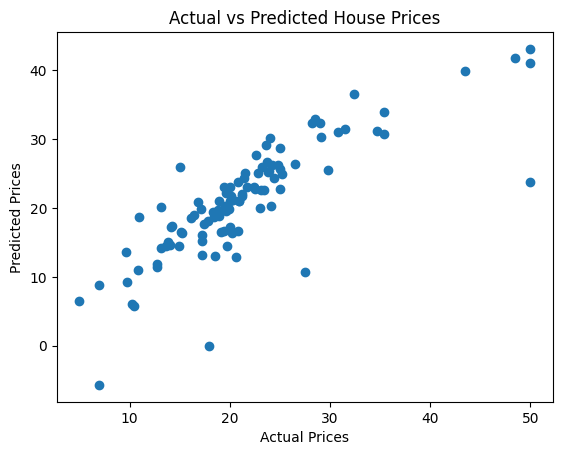

In [15]:
# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()